# Module 4 - Class 1: Linear Regression and Gradient Descent

**Dataset:** Superstore Sales  
**Objective:** Understand linear regression, evaluation metrics, and gradient descent.

### What you will learn
- Simple and multiple linear regression
- MSE, RMSE, MAE, R-squared
- Coefficient interpretation
- Residual analysis
- Polynomial features
- Gradient descent intuition

---

## 0. Setup

In [15]:
# Import core data manipulation and visualization libraries
import pandas as pd          # for loading and working with tabular data
import numpy as np           # for numerical operations and array math
import matplotlib.pyplot as plt  # for creating plots and charts
import seaborn as sns        # for prettier statistical visualizations

# Import machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split      # splits data into train/test sets
from sklearn.linear_model import LinearRegression         # linear regression model
from sklearn.preprocessing import PolynomialFeatures      # generates polynomial feature combinations
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # evaluation metrics

# Suppress unnecessary warning messages to keep output clean
import warnings
warnings.filterwarnings('ignore')

print("Setup complete.")

Setup complete.


## 1. Load Data

In [23]:
# Alternative: manually upload the file if the URL above doesn't work
# Uncomment the lines below and run this cell if you need to upload manually
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0], encoding='windows-1252')

# Confirm the data loaded correctly by printing its dimensions (rows, columns)
print(f"Shape: {df.shape}")

# Preview the first 5 rows to understand the structure of the dataset
df.head()

Saving archive (3).zip to archive (3) (2).zip
Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [24]:
# Show basic statistics for the four key numeric columns
# This gives us count, mean, std, min/max, and quartiles for each column
# Helps spot outliers and understand the value ranges before modeling
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


## 2. Simple Linear Regression: Sales ~ Discount

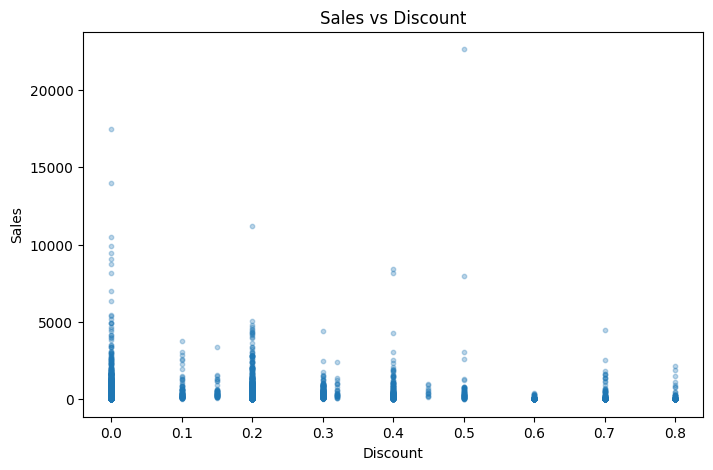

In [25]:
# Visualize the raw relationship between Discount and Sales before modeling
# alpha=0.3 makes points semi-transparent so dense clusters are visible
# s=10 makes individual points smaller for a cleaner look
plt.figure(figsize=(8, 5))
plt.scatter(df['Discount'], df['Sales'], alpha=0.3, s=10)
plt.xlabel('Discount')
plt.ylabel('Sales')
plt.title('Sales vs Discount')
plt.show()

In [26]:
# Prepare the single feature (Discount) as a 2D array — sklearn requires shape (n_samples, n_features)
X_simple = df[['Discount']]
y = df['Sales']  # target variable we want to predict

# Split data: 80% for training, 20% for testing
# random_state=42 ensures reproducible splits every time you run this
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Create and train the simple linear regression model on the training data
lr_simple = LinearRegression()
lr_simple.fit(X_train, y_train)

# Generate predictions on the unseen test data
y_pred_simple = lr_simple.predict(X_test)

# Print the learned model parameters
# coef_[0] is the slope — how much Sales changes per unit of Discount
# intercept_ is the baseline Sales when Discount = 0
print(f"Coefficient (slope): {lr_simple.coef_[0]:.4f}")
print(f"Intercept: {lr_simple.intercept_:.4f}")
print(f"\nInterpretation: For each 1-unit increase in Discount,")
print(f"Sales changes by {lr_simple.coef_[0]:.2f} on average.")

Coefficient (slope): -126.7518
Intercept: 245.5065

Interpretation: For each 1-unit increase in Discount,
Sales changes by -126.75 on average.


## 3. Multiple Linear Regression

In [ ]:
# Use three features instead of one to capture more of the variance in Sales
# Discount, Quantity, and Profit are all numerically available without extra encoding
X_multi = df[['Discount', 'Quantity', 'Profit']]

# Split the multi-feature dataset into train and test sets (same 80/20 ratio)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# Train the multiple linear regression model
lr_multi = LinearRegression()
lr_multi.fit(X_train_m, y_train_m)

# Generate predictions on the test set
y_pred_multi = lr_multi.predict(X_test_m)

# Create a DataFrame to display each feature alongside its learned coefficient
# A positive coefficient means the feature increases Sales; negative means it decreases Sales
coef_df = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': lr_multi.coef_
})
print("Coefficients:")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {lr_multi.intercept_:.4f}")

## 4. Evaluation Metrics

In [ ]:
def evaluate_regression(y_true, y_pred, model_name="Model"):
    """
    Compute and print the four standard regression evaluation metrics.

    Parameters:
        y_true     : actual target values from the test set
        y_pred     : predicted values from the model
        model_name : label to display in the output header

    Returns:
        dict with keys 'model', 'MSE', 'RMSE', 'MAE', 'R2'
    """
    # MSE: average of squared errors — penalizes large mistakes heavily
    mse = mean_squared_error(y_true, y_pred)

    # RMSE: square root of MSE — same unit as the target (Sales in dollars)
    rmse = np.sqrt(mse)

    # MAE: average of absolute errors — more robust to outliers than RMSE
    mae = mean_absolute_error(y_true, y_pred)

    # R2: proportion of variance in Sales explained by the model
    # 1.0 = perfect, 0.0 = no better than predicting the mean, negative = worse than mean
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R2:   {r2:.4f}")
    print()

    # Return as a dict so we can collect results into a comparison table later
    return {'model': model_name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Evaluate the simple model (1 feature) and the multiple model (3 features)
metrics_simple = evaluate_regression(y_test, y_pred_simple, "Simple LR (Discount only)")
metrics_multi = evaluate_regression(y_test_m, y_pred_multi, "Multiple LR (Discount + Quantity + Profit)")

## 5. Coefficient Interpretation

In [ ]:
# Horizontal bar chart makes it easy to compare coefficient magnitudes and directions
# Bars to the right of 0 indicate a positive effect on Sales; bars to the left indicate negative
plt.figure(figsize=(8, 4))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Multiple Linear Regression Coefficients')

# Vertical dashed line at 0 helps visually separate positive from negative coefficients
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Each coefficient tells you: holding other features constant,")
print("a 1-unit increase in this feature changes Sales by this amount.")

## 6. Residual Plot

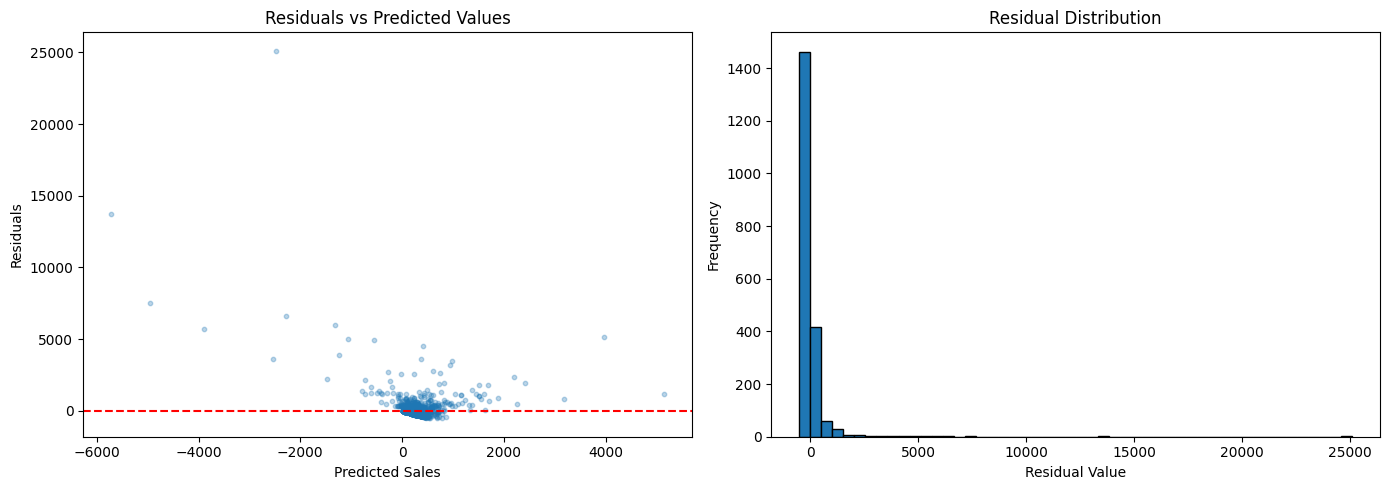

Ideal residual plot: randomly scattered around 0, no pattern.
A pattern suggests the model is missing something (non-linearity, interactions, etc.).


In [17]:
# Residuals = actual values minus predicted values
# A residual of 0 means the model predicted perfectly for that point
residuals = y_test_m - y_pred_multi

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Residuals vs Predicted Values
# We want to see no pattern here — just a random cloud around the red dashed line at 0
# A funnel shape would indicate heteroscedasticity (variance grows with prediction size)
# A curve would suggest a non-linear relationship the model isn't capturing
axes[0].scatter(y_pred_multi, residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color='red', linestyle='--')  # the ideal zero-error line
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted Values')

# Right plot: Distribution of Residuals
# Ideally this should look like a bell curve centered at 0 (normal distribution)
# A skewed distribution suggests systematic over- or under-prediction
axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

print("Ideal residual plot: randomly scattered around 0, no pattern.")
print("A pattern suggests the model is missing something (non-linearity, interactions, etc.).")

## 7. Polynomial Features

Linear regression assumes a linear relationship. Polynomial features can capture non-linear patterns.

**Tasks:**
1. Create polynomial features of degree 2 and degree 3
2. Train linear regression on each
3. Compare all models (linear, degree 2, degree 3) using the evaluation metrics

In [18]:
# ── DEGREE 2 POLYNOMIAL REGRESSION ───────────────────────────────────────────

# Step 1: Create the polynomial transformer for degree 2
# include_bias=False avoids adding a redundant all-ones column (LinearRegression handles the intercept itself)
# For features [A, B, C], degree=2 generates: A, B, C, A^2, A*B, A*C, B^2, B*C, C^2
poly2 = PolynomialFeatures(degree=2, include_bias=False)

# Step 2: Fit on training data and transform it
# fit_transform learns the feature names then expands the training set
X_train_poly2 = poly2.fit_transform(X_train_m)

# Step 3: Transform the test set using the same polynomial mapping (do NOT re-fit on test data)
X_test_poly2 = poly2.transform(X_test_m)

# Step 4: Train a standard LinearRegression on the expanded polynomial features
lr_poly2 = LinearRegression()
lr_poly2.fit(X_train_poly2, y_train_m)

# Step 5: Predict and evaluate
y_pred_poly2 = lr_poly2.predict(X_test_poly2)
metrics_poly2 = evaluate_regression(y_test_m, y_pred_poly2, "Polynomial LR (Degree 2)")


# ── DEGREE 3 POLYNOMIAL REGRESSION ───────────────────────────────────────────

# Same steps as degree 2, but now also add cubic terms (A^3, A^2*B, A*B*C, B^3, etc.)
# Warning: degree 3 creates many more features — can lead to overfitting on small datasets
poly3 = PolynomialFeatures(degree=3, include_bias=False)

# Fit and transform training data with degree-3 expansion
X_train_poly3 = poly3.fit_transform(X_train_m)

# Transform test data using the fitted degree-3 transformer
X_test_poly3 = poly3.transform(X_test_m)

# Train linear regression on the degree-3 polynomial features
lr_poly3 = LinearRegression()
lr_poly3.fit(X_train_poly3, y_train_m)

# Predict and evaluate
y_pred_poly3 = lr_poly3.predict(X_test_poly3)
metrics_poly3 = evaluate_regression(y_test_m, y_pred_poly3, "Polynomial LR (Degree 3)")

--- Polynomial LR (Degree 2) ---
MSE:  473873.85
RMSE: 688.38
MAE:  190.56
R2:   0.1978

--- Polynomial LR (Degree 3) ---
MSE:  467995.52
RMSE: 684.10
MAE:  177.83
R2:   0.2077



In [19]:
# ── MODEL COMPARISON TABLE ────────────────────────────────────────────────────

# Collect all four metrics dictionaries into a list and convert to a DataFrame
# This makes it easy to compare all models side by side
all_metrics = [metrics_simple, metrics_multi, metrics_poly2, metrics_poly3]
comparison_df = pd.DataFrame(all_metrics)

# Set 'model' as the index so each row is labeled by model name
comparison_df = comparison_df.set_index('model')

# Round all metric values to 2 decimal places for readability
comparison_df = comparison_df.round(2)

print("Model Comparison Table:")
print(comparison_df.to_string())

# Quick interpretation hints:
# Lower MSE / RMSE / MAE = better (fewer prediction errors)
# Higher R2 = better (model explains more variance in Sales)
print("\nBest R2:", comparison_df['R2'].idxmax())
print("Lowest RMSE:", comparison_df['RMSE'].idxmin())

Model Comparison Table:
                                                  MSE    RMSE     MAE    R2
model                                                                      
Simple LR (Discount only)                   592714.18  769.88  286.23 -0.00
Multiple LR (Discount + Quantity + Profit)  680377.46  824.85  245.08 -0.15
Polynomial LR (Degree 2)                    473873.85  688.38  190.56  0.20
Polynomial LR (Degree 3)                    467995.52  684.10  177.83  0.21

Best R2: Polynomial LR (Degree 3)
Lowest RMSE: Polynomial LR (Degree 3)


## 8. Gradient Descent Visualization (Demo)

This cell shows how gradient descent minimizes the loss function step by step. You do not need to modify this -- just run it and observe.

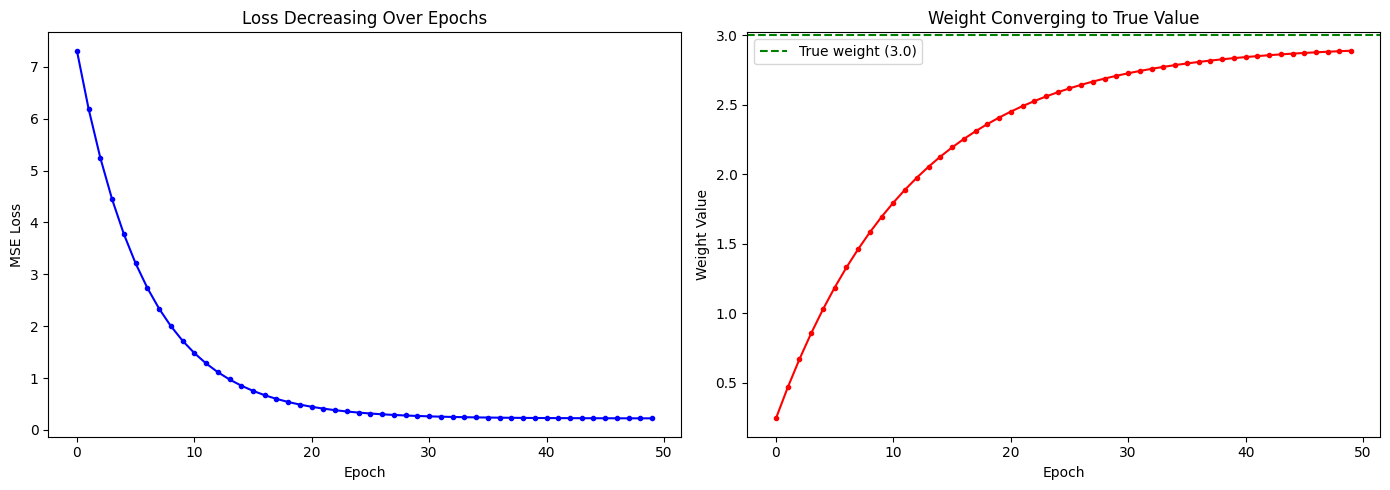

Final weight: 2.8889 (true: 3.0)
Final loss: 0.2224


In [20]:
# ── GRADIENT DESCENT DEMO ─────────────────────────────────────────────────────
# Goal: manually find the weight w that best fits y = w * x
# This demonstrates what sklearn's LinearRegression does internally (conceptually)

np.random.seed(42)  # fix randomness for reproducibility

# Generate synthetic data: y = 3.0 * x + small noise
# The true relationship has slope 3.0 — we want gradient descent to discover this
x_gd = np.random.randn(100)                          # 100 random input values
y_gd = 3.0 * x_gd + np.random.randn(100) * 0.5      # true weight = 3.0, noise std = 0.5

# Initialize weight at 0 (far from the true value of 3.0)
w = 0.0

# Learning rate controls how big each update step is
# Too large → overshoots and diverges; too small → converges very slowly
lr = 0.05

n_epochs = 50    # number of full passes through the dataset
history = []     # store w and loss at each epoch to plot later

for epoch in range(n_epochs):
    # Forward pass: compute predictions with current weight
    y_hat = w * x_gd

    # Compute MSE loss for this epoch
    loss = np.mean((y_gd - y_hat) ** 2)

    # Compute gradient of MSE with respect to w
    # Derived by differentiating MSE = mean((y - w*x)^2) with respect to w
    # Result: d(MSE)/dw = -2 * mean(x * (y - y_hat))
    grad = -2 * np.mean(x_gd * (y_gd - y_hat))

    # Gradient descent update rule: move w in the opposite direction of the gradient
    # The gradient points uphill; we subtract it to go downhill (minimize loss)
    w = w - lr * grad

    # Record progress for plotting
    history.append({'epoch': epoch, 'weight': w, 'loss': loss})

history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Loss curve — should decrease and flatten as the model converges
# A smooth downward curve indicates a good learning rate
axes[0].plot(history_df['epoch'], history_df['loss'], 'b-o', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss Decreasing Over Epochs')

# Right plot: Weight trajectory — should converge toward 3.0 (the true weight)
# Green dashed line shows where the weight should end up
axes[1].plot(history_df['epoch'], history_df['weight'], 'r-o', markersize=3)
axes[1].axhline(y=3.0, color='green', linestyle='--', label='True weight (3.0)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Weight Value')
axes[1].set_title('Weight Converging to True Value')
axes[1].legend()

plt.tight_layout()
plt.show()

# Final check: how close did gradient descent get to the true weight of 3.0?
print(f"Final weight: {w:.4f} (true: 3.0)")
print(f"Final loss: {history_df['loss'].iloc[-1]:.4f}")

---
## Summary

| Concept | Details |
|---------|---------|
| Simple LR | One feature predicting target |
| Multiple LR | Multiple features |
| MSE / RMSE | Penalize large errors more |
| MAE | Average absolute error (robust to outliers) |
| R-squared | Proportion of variance explained (0 to 1) |
| Residuals | Predicted - Actual; should be random around 0 |
| Polynomial | Captures non-linear relationships |
| Gradient Descent | Iteratively adjusts weights to minimize loss |